# Tema : Modelos Prophet y LSTM

![](src/img/logo_utb.png)
![](src/img/logo_etd.png)
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

# Ejercicio 1. Demanda de electricidad cada media hora

- Una aplicación común de estos modelos es la modelización de la demanda de electricidad. Tenemos una muestra la demanda de electricidad cada media hora (MWh) en Victoria, Australia, durante el período 2012-2014, junto con las temperaturas (en grados Celsius) para el mismo período en Melbourne (la ciudad más grande de Victoria).


In [127]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos Prophet
from prophet import Prophet
from prophet.diagnostics import performance_metrics
from prophet.diagnostics import cross_validation
from prophet.plot import plot_cross_validation_metric

# Modelo LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras

import warnings
warnings.filterwarnings('ignore')


In [128]:
# datos de electricidad
vic_elec = pd.read_csv("data/vic_elec.csv", parse_dates=["ds"])

vic_elec_df = (
    vic_elec
    .pivot(index=["ds", "Holiday"], columns="unique_id", values="y")
    .reset_index().rename_axis(None, axis="columns")
    .assign(ds=lambda x: pd.to_datetime(x["ds"]).dt.normalize())
    .groupby(["ds", "Holiday"])
    .agg({
        "Demand": "sum",
        "Temperature": "max"
    })
    .reset_index()
    .assign(
        Demand=lambda x: x["Demand"] / 1e3,
        weekend=lambda x: x["ds"].dt.dayofweek.isin([5, 6]),
        Working_Day=lambda x: ~x["Holiday"] & ~x["weekend"],
        Cooling=lambda x: x["Temperature"].clip(lower=18)
    )
    .drop(columns=["weekend", "Holiday"])
)

vic_elec_df.head()


,ds,Demand,Temperature,Working_Day,Cooling
0,2012-01-01,222.437912,32.7,False,32.7
1,2012-01-02,257.964724,39.6,False,39.6
2,2012-01-03,267.098605,31.8,True,31.8
3,2012-01-04,222.742287,25.1,True,25.1
4,2012-01-05,210.585240,21.2,True,21.2


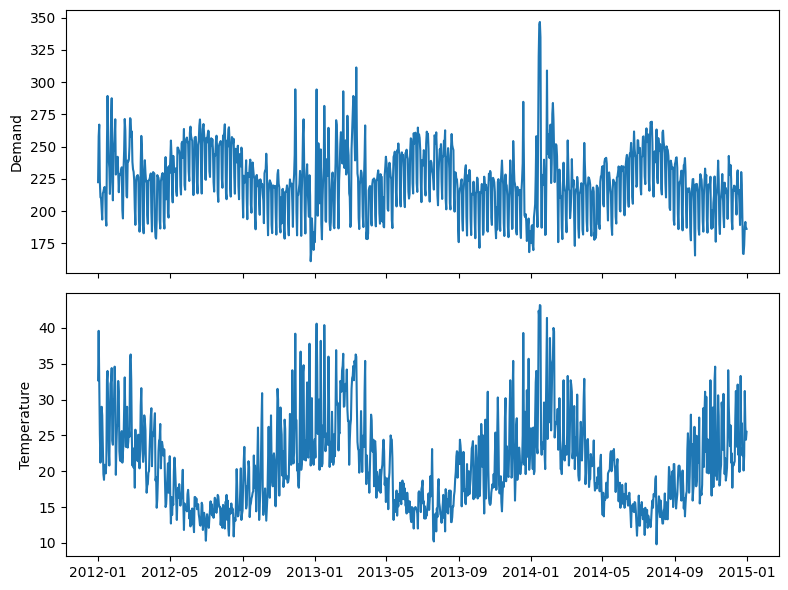

In [74]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(vic_elec_df["ds"], vic_elec_df["Demand"])
axes[0].set_ylabel("Demand")
axes[1].plot(vic_elec_df["ds"], vic_elec_df["Temperature"])
axes[1].set_ylabel("Temperature")
plt.tight_layout()
plt.show()

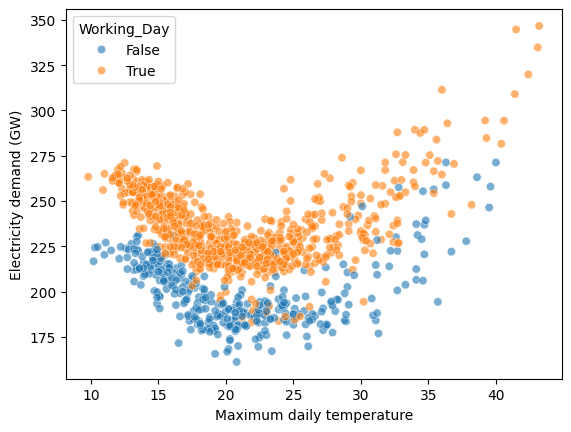

In [77]:
fig, ax = plt.subplots()
sns.scatterplot(data=vic_elec_df, x="Temperature", y="Demand",
    hue="Working_Day", palette="tab10", alpha=0.6, ax=ax)
ax.set(
    xlabel="Maximum daily temperature",
    ylabel="Electricity demand (GW)",
)
plt.show()

Si se representa la demanda de electricidad en función de la temperatura, se observa que existe una relación no lineal entre ambas, con un aumento de la demanda para temperaturas bajas (debido a la calefacción) y un aumento para temperaturas altas (debido a la refrigeración).

19:59:12 - cmdstanpy - INFO - Chain [1] start processing
19:59:12 - cmdstanpy - INFO - Chain [1] done processing


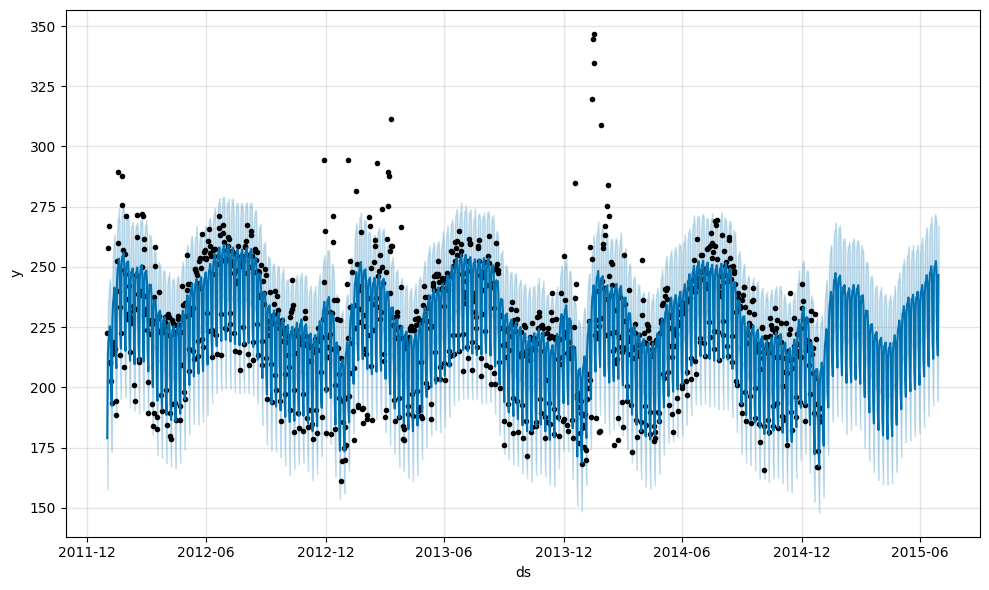

In [78]:
# Test entrenamiento y prueba
# Estimar solo demanda : Dataframe must have columns "ds" and "y" with the dates and values respectively.
demanda = vic_elec_df[["ds", "Demand"]].copy()
demanda.rename(columns={"Demand" : "y"}, inplace=True)

# Definir y ajustar el modelo
model = Prophet()
model.fit(demanda)

# Predecir 180 dias de demanda (6 meses)
future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)
fig1 = model.plot(forecast)

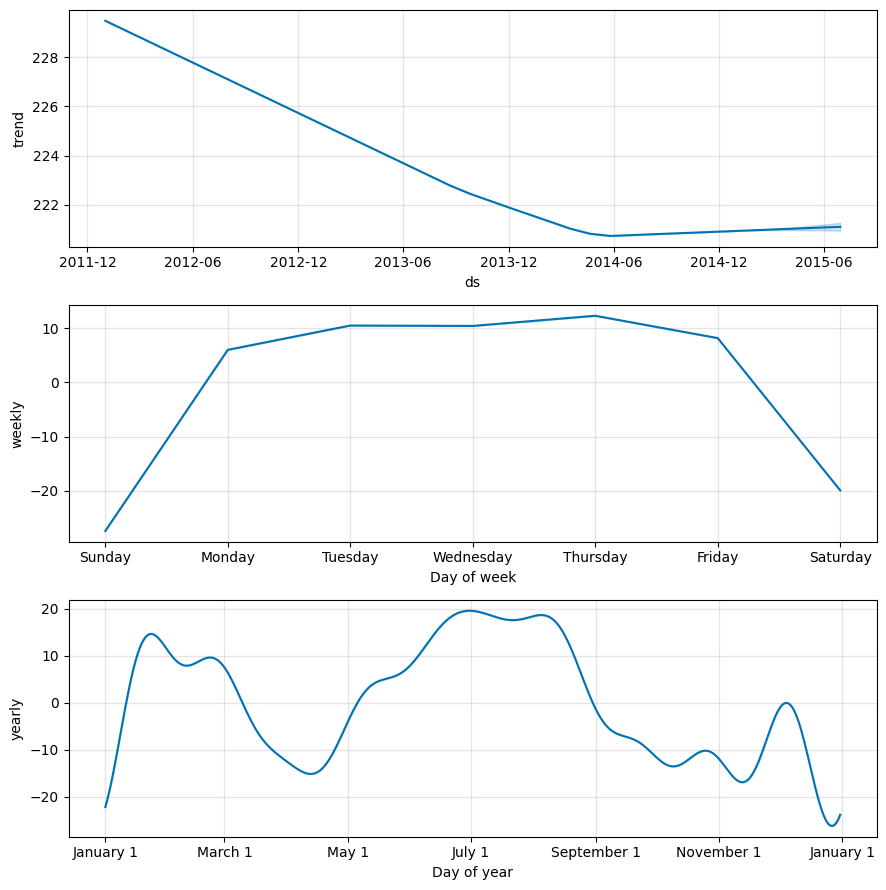

In [65]:
fig2 = model.plot_components(forecast)

In [81]:
df_cv = cross_validation(
    model=model,
    initial='730 days',   # Tamaño del conjunto inicial de entrenamiento
    period='180 days',    # Frecuencia de los cortes de validación
    horizon='365 days',   # Horizonte de pronóstico a evaluar
    parallel='processes'  # Paralelización: 'processes' | 'threads' | None
)
df_p = performance_metrics(df_cv)
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days,1911.522820,43.720965,29.281737,0.110594,0.083295,0.119638,0.527778
1,37 days,1926.194322,43.888430,29.474221,0.109294,0.083295,0.119176,0.527778
2,38 days,1991.217132,44.623056,30.306043,0.111027,0.083295,0.121679,0.527778
3,39 days,2112.794331,45.965143,31.664683,0.115132,0.083295,0.126972,0.527778
4,40 days,2184.246807,46.735926,32.851956,0.119540,0.086723,0.132090,0.500000
...,...,...,...,...,...,...,...,...
325,361 days,259.710295,16.115530,11.825191,0.057741,0.035363,0.058854,0.694444
326,362 days,273.129417,16.526628,12.162114,0.059616,0.035363,0.060941,0.666667
327,363 days,269.792973,16.425376,11.957782,0.058512,0.024340,0.059773,0.666667
328,364 days,271.204203,16.468279,12.014425,0.059093,0.024340,0.060245,0.666667


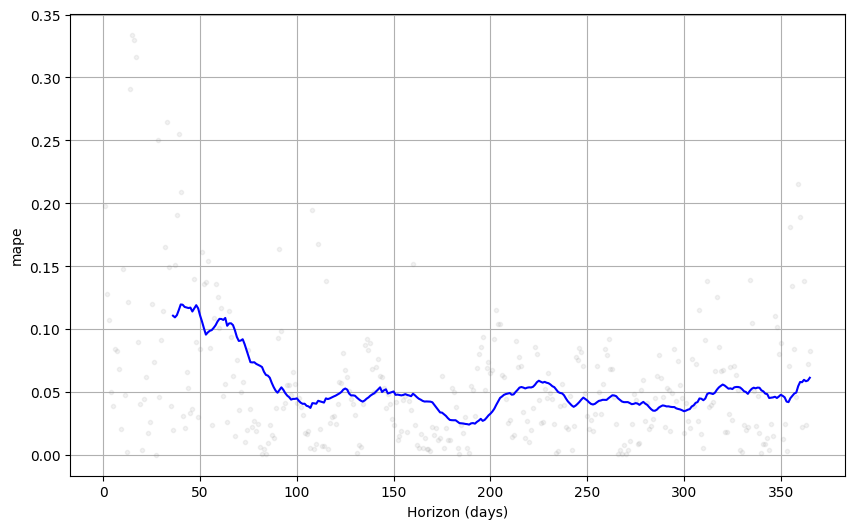

In [82]:
fig = plot_cross_validation_metric(df_cv, metric='mape')

20:17:54 - cmdstanpy - INFO - Chain [1] start processing
20:17:54 - cmdstanpy - INFO - Chain [1] done processing


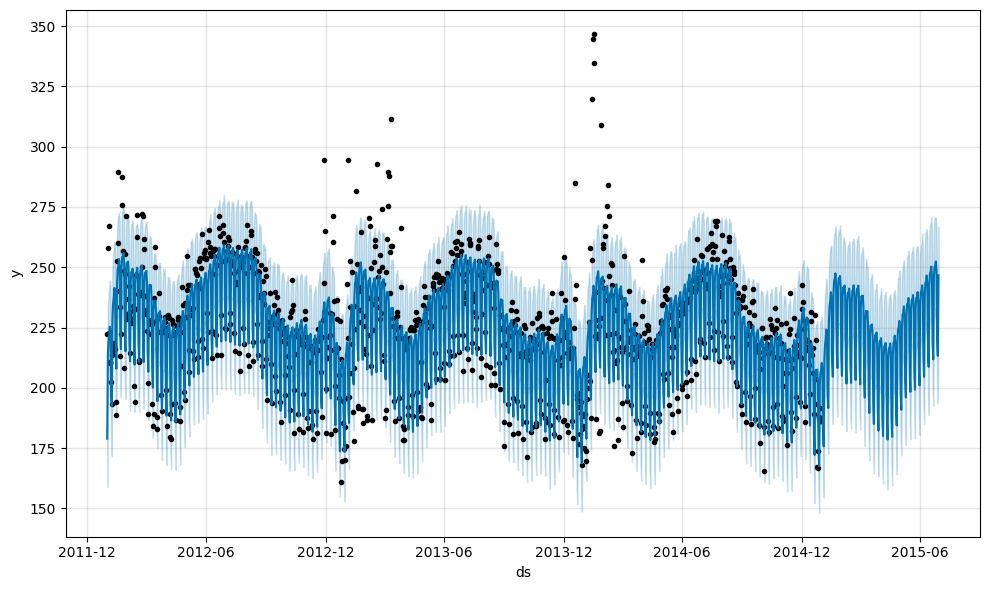

In [85]:
# Modelo prophet 2 incluyendo regresoras
demanda_exog = vic_elec_df.copy()
demanda_exog.rename(columns={"Demand" : "y"}, inplace=True)

#  Construir el modelo
modelo_exog = Prophet()
modelo_exog.add_regressor("Temperature")
modelo_exog.add_regressor("Working_Day")

# Estimar el modelo
modelo_exog.fit(demanda_exog)

# Predecir 180 dias de demanda (6 meses)
future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)
fig1 = model.plot(forecast)

In [86]:
df_cv = cross_validation(
    model=modelo_exog,
    initial='730 days',   # Tamaño del conjunto inicial de entrenamiento
    period='180 days',    # Frecuencia de los cortes de validación
    horizon='365 days',   # Horizonte de pronóstico a evaluar
    parallel='processes'  # Paralelización: 'processes' | 'threads' | None
)
df_p = performance_metrics(df_cv)
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days,1067.299929,32.669557,22.120362,0.083338,0.069101,0.088482,0.500000
1,37 days,1086.357174,32.959933,22.728526,0.085274,0.071317,0.090564,0.472222
2,38 days,1112.671422,33.356730,23.168716,0.085734,0.071317,0.091467,0.472222
3,39 days,1166.572492,34.155124,24.004268,0.088048,0.071317,0.094353,0.472222
4,40 days,1192.840092,34.537517,24.830100,0.091351,0.075625,0.097887,0.444444
...,...,...,...,...,...,...,...,...
325,361 days,69.361535,8.328357,6.392987,0.030413,0.025738,0.031038,0.944444
326,362 days,72.285097,8.502064,6.639917,0.031735,0.027400,0.032404,0.944444
327,363 days,76.991012,8.774452,6.864222,0.032885,0.027400,0.033461,0.944444
328,364 days,81.789037,9.043729,7.021221,0.034030,0.027400,0.034435,0.916667


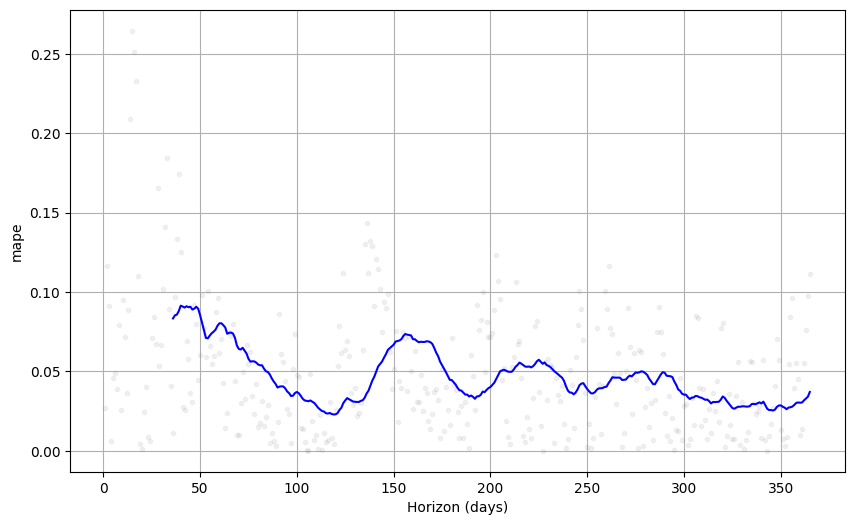

In [87]:
fig = plot_cross_validation_metric(df_cv, metric='mape')

## Modelo usando LSTM
Usando el mismo dataset de temperatura procedemos a pronosticar por LSTM

### Pasos :
1. Escalar los datos entre 0-1
2. Convertir la serie de tiempo en secuencias. Transformamos los datos de series temporales en ventanas deslizantes para la entrada de LSTM.
3. Dividido en conjuntos de prueba y entrenamiento
4. Construí el modelo LSTM

In [132]:
df = vic_elec_df.copy()
df.set_index('ds', inplace=True)
df.head()

,Demand,Temperature,Working_Day,Cooling
ds,,,,
2012-01-01,222.437912,32.7,False,32.7
2012-01-02,257.964724,39.6,False,39.6
2012-01-03,267.098605,31.8,True,31.8
2012-01-04,222.742287,25.1,True,25.1
2012-01-05,210.585240,21.2,True,21.2


$$\hat{x}_i = \frac{x_i - x_{\min}}{x_{\max} - x_{\min}}$$

Donde:

| Símbolo | Descripción |
|---------|-------------|
| $x_i$ | Valor original |
| $\hat{x}_i$ | Valor normalizado $\in [0, 1]$ |
| $x_{\min}$ | Mínimo de la serie |
| $x_{\max}$ | Máximo de la serie |

Para un rango personalizado $[a, b]$:

$$\hat{x}_i = a + \frac{(x_i - x_{\min})(b - a)}{x_{\max} - x_{\min}}$$

Y la **transformación inversa** para recuperar la escala original:

$$x_i = \hat{x}_i \cdot (x_{\max} - x_{\min}) + x_{\min}$$

In [152]:
# Escalar los valores de la serie
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

print(f"Dimension matriz {scaled_data.ndim}")
print("\nEncabezado matriz")
for i in range(16):
    print(f"Fila {i} : {scaled_data[i]}")

Dimension matriz 2

Encabezado matriz
Fila 0 : [0.33042727 0.68562874 0.         0.58333333]
Fila 1 : [0.5218241  0.89221557 0.         0.85714286]
Fila 2 : [0.57103189 0.65868263 1.         0.54761905]
Fila 3 : [0.33206706 0.45808383 1.         0.28174603]
Fila 4 : [0.2665723  0.34131737 1.         0.12698413]
Fila 5 : [0.26474759 0.41317365 1.         0.22222222]
Fila 6 : [0.22315565 0.5748503  0.         0.43650794]
Fila 7 : [0.17405621 0.53892216 0.         0.38888889]
Fila 8 : [0.28391287 0.4251497  1.         0.23809524]
Fila 9 : [0.29046631 0.29341317 1.         0.06349206]
Fila 10 : [0.30296309 0.26946108 1.         0.03174603]
Fila 11 : [0.31032766 0.33233533 1.         0.11507937]
Fila 12 : [0.29558353 0.31137725 1.         0.08730159]
Fila 13 : [0.17896586 0.29640719 0.         0.06746032]
Fila 14 : [0.14861989 0.34730539 0.         0.13492063]
Fila 15 : [0.49205761 0.68862275 1.         0.58730159]


## La serie de tiempo es 
| $t_1$ | $t_2$ | $t_3$ | $t_4$ | $t_5$ | $t_6$ | $t_7$ | $t_8$ | $t_9$ | $t_{10}$ |
|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:------:|
| $y_1$ | $y_2$ | $y_3$ | $y_4$ | $y_5$ | $y_6$ | $y_7$ | $y_8$ | $y_9$ | $y_{10}$ |

## Con tamaño de ventana 4 y horizonte 1 tenemos una secuencia que se desliza un paso a la vez

| Ventana (X) | | | | Objetivo (y) |
|:-----------:|:-----------:|:-----------:|:-----------:|:------------:|
| $y_1$ | $y_2$ | $y_3$ | $y_4$ | $y_5$ |
| $y_2$ | $y_3$ | $y_4$ | $y_5$ | $y_6$ |
| $y_3$ | $y_4$ | $y_5$ | $y_6$ | $y_7$ |
| $y_4$ | $y_5$ | $y_6$ | $y_7$ | $y_8$ |
| $y_5$ | $y_6$ | $y_7$ | $y_8$ | $y_9$ |
| $y_6$ | $y_7$ | $y_8$ | $y_9$ | $y_{10}$ |
| **paso 1** | **paso 2** | **paso 3** | **paso 4** | **horizonte** |

## Generando estas muestras para la red neuronal

| | **Muestra 1** | **Muestra 2** | **Muestra 3** | **Muestra 4** | **Muestra 5** | **Muestra 6** |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| paso 1 | $y_1$ | $y_2$ | $y_3$ | $y_4$ | $y_5$ | $y_6$ |
| paso 2 | $y_2$ | $y_3$ | $y_4$ | $y_5$ | $y_6$ | $y_7$ |
| paso 3 | $y_3$ | $y_4$ | $y_5$ | $y_6$ | $y_7$ | $y_8$ |
| paso 4 | $y_4$ | $y_5$ | $y_6$ | $y_7$ | $y_8$ | $y_9$ |
| **objetivo** | $y_5$ | $y_6$ | $y_7$ | $y_8$ | $y_9$ | $y_{10}$ |

Con `window_size = 4`, `horizon = 1` y serie de $T = 10$, el número de muestras es:

$$n\_samples = T - window\_size - horizon + 1 = 10 - 4 - 1 + 1 = 6$$

Con `window_size = 4` y `horizon = 1`, shape resultante:

| Tensor | Dimensiones | Valores |
|--------|------------|---------|
| `X` | `(n_samples, window_size, n_features)` | `(6, 4, 1)` |
| `y` | `(n_samples, horizon)` | `(6, 1)` |

Un tensor es una generalización matemática de escalares, vectores y matrices a cualquier número de dimensiones.

| | **Escalar** | **Vector** | **Matriz** | **Tensor 3D** |
|---|:---:|:---:|:---:|:---:|
| **Ejes** | 0 | 1 | 2 | 3 |
| **Shape** | `()` | `(3,)` | `(3, 3)` | `(n, m, p)` |
| **Índice** | — | $x_i$ | $x_{ij}$ | $x_{ijk}$ |
| **Ejemplo** | $5$ | $[1, 2, 3]$ | $\begin{bmatrix}1&2&3\\4&5&6\\7&8&9\end{bmatrix}$ | $\mathbf{X}[i,j,k]$ |
| **En NumPy** | `np.array(5)` | `np.array([1,2,3])` | `np.zeros((3,3))` | `np.zeros((n,m,p))` |
| **En LSTM** | Un valor $y_t$ | Una ventana $[y_1 \dots y_w]$ | Ventanas de una variable | Ventanas de múltiples variables |

In [154]:
# Crear secuencia de datos de la serie 
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        # En NumPy usar siempre slicing estándar [start:stop:step]
        X.append(data[i:i + window])
        y.append(data[i + window, 0]) # indice 0 es la variable a modelar
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 15)

print("Secuencia de la ventana en la primera muestra X\n")
print(X[0])
print("\nSecuencia de la ventana en la primera muestra y posicion 15 en la serie")
print(y[0])

Secuencia de la ventana en la primera muestra X

[[0.33042727 0.68562874 0.         0.58333333]
 [0.5218241  0.89221557 0.         0.85714286]
 [0.57103189 0.65868263 1.         0.54761905]
 [0.33206706 0.45808383 1.         0.28174603]
 [0.2665723  0.34131737 1.         0.12698413]
 [0.26474759 0.41317365 1.         0.22222222]
 [0.22315565 0.5748503  0.         0.43650794]
 [0.17405621 0.53892216 0.         0.38888889]
 [0.28391287 0.4251497  1.         0.23809524]
 [0.29046631 0.29341317 1.         0.06349206]
 [0.30296309 0.26946108 1.         0.03174603]
 [0.31032766 0.33233533 1.         0.11507937]
 [0.29558353 0.31137725 1.         0.08730159]
 [0.17896586 0.29640719 0.         0.06746032]
 [0.14861989 0.34730539 0.         0.13492063]]

Secuencia de la ventana en la primera muestra y posicion 15 en la serie
0.49205760617125727


In [155]:
# Dividir en set de prueba y entrenamiento
split = int(0.85 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [156]:
# Construir el modelo LSTM
# Definiremos la estructura de la red neuronal. Aquí:
#  1. LSTM aprende patrones temporales
#  2. El dropout reduce el sobreajuste
#  3. La capa densa genera la temperatura del día siguiente
#  4. El error cuadrático medio se utiliza como función de pérdida

model = keras.Sequential()
model.add(
    keras.layers.LSTM(
        100, # El argumento define el número de unidades (neuronas) de la capa LSTM
        input_shape=(
            X_train.shape[1],  # Pasos de tiempo por ventana
            X_train.shape[2]   # Variables en cada paso
            )
        )
    )

# Durante el entrenamiento, el Dropout apaga aleatoriamente el 20% de las neuronas de la capa anterior
# en cada secuecienca para evitar el overfitting
model.add(keras.layers.Dropout(0.2))

# Capa de salida completamente conectada que colapsa los estados ocultos a un solo valor y^​t ​= Wy​ x ht​ + by​
model.add(keras.layers.Dense(1))

# Define la función de pérdida, el optimizador y las métricas de evaluación del entrenamiento
model.compile(loss="mse", optimizer="adam", metrics=["mae"])
model.summary()
 

Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 42,101 (164.46 KB)
 Trainable params: 42,101 (164.46 KB)
 Non-trainable params: 0 (0.00 B)


In [ ]:
# Entrenar el modelo 
# El modelo aprende los patrones climáticos a partir de datos históricos y se entrena durante 30 épocas.
history = model.fit(
    X_train, y_train,
    epochs     = 30, # Una época es una pasada completa del modelo por todo el conjunto de entrenamiento. 
    batch_size = 16, # Define el número de muestras que el modelo procesa antes de actualizar los pesos. 
    shuffle    = False   # Preservar orden temporal
)


Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0062 - mae: 0.0564
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065 - mae: 0.0580
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0064 - mae: 0.0578
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0062 - mae: 0.0566
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060 - mae: 0.0552
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056 - mae: 0.0539
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0058 - mae: 0.0533
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0058 - mae: 0.0534
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0057 - mae: 0.0541
Epoch 10/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0057 - mae: 0.0538
Epoch 11/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0058 - mae: 0.0535
Epoch 12/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0056 - mae: 0.0548
Epoch 13/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11m

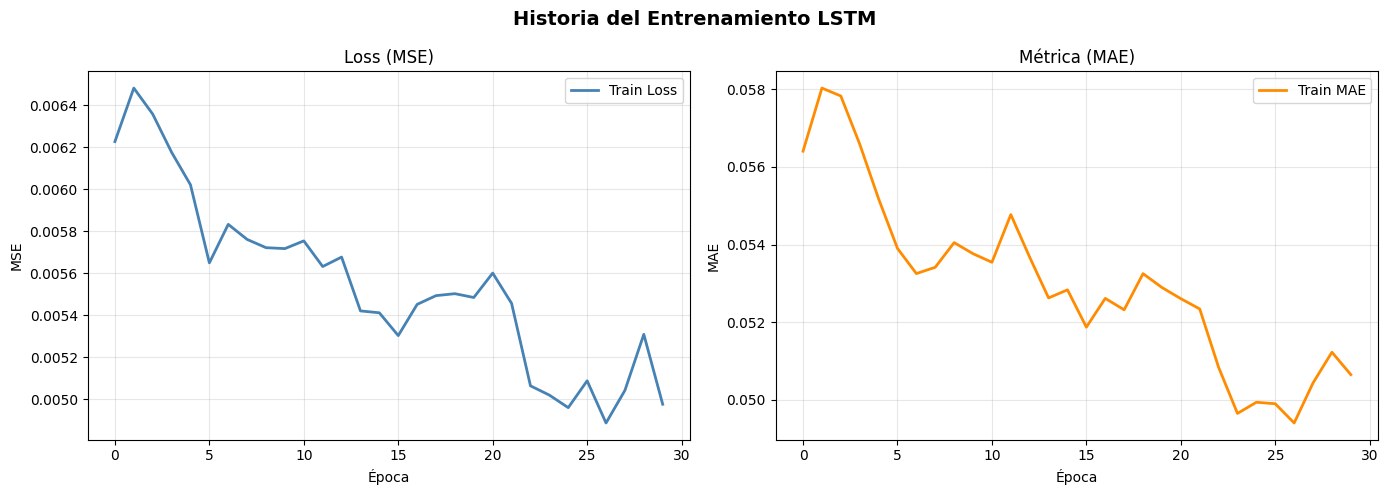

In [159]:
# Graficar historia del entrenamiento
# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (MSE)
axes[0].plot(history.history["loss"], label="Train Loss", linewidth=2, color="steelblue")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Métrica (MAE)
axes[1].plot(history.history["mae"], label="Train MAE", linewidth=2, color="darkorange")
axes[1].set_title("Métrica (MAE)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Historia del Entrenamiento LSTM", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor              = "val_loss",  # Métrica a observar
    patience             = 10,          # Épocas sin mejora antes de detener
    restore_best_weights = True         # Restaurar pesos del mejor epoch
)

# Entrenamiento con early stopping
history = model.fit(
    X_train, y_train,
    epochs          = 100, 
    batch_size      = 32,
    validation_split = 0.1, # Validación (10%) en cada epoca de la red
    callbacks       = [early_stop],
    shuffle         = False,
    verbose         = 1
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0053 - mae: 0.0507 - val_loss: 0.0017 - val_mae: 0.0302
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0052 - mae: 0.0502 - val_loss: 0.0017 - val_mae: 0.0291
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0049 - mae: 0.0489 - val_loss: 0.0017 - val_mae: 0.0296
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - mae: 0.0483 - val_loss: 0.0017 - val_mae: 0.0298
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0050 - mae: 0.0492 - val_loss: 0.0017 - val_mae: 0.0300
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0048 - mae: 0.0499 - val_loss: 0.0017 - val_mae: 0.0297
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0051 - mae: 0.0493 - val_loss: 0.0017 - val_mae: 0.0298
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0047 - mae: 0.0466 - val_loss: 0.0017 - val_mae: 0.0295
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

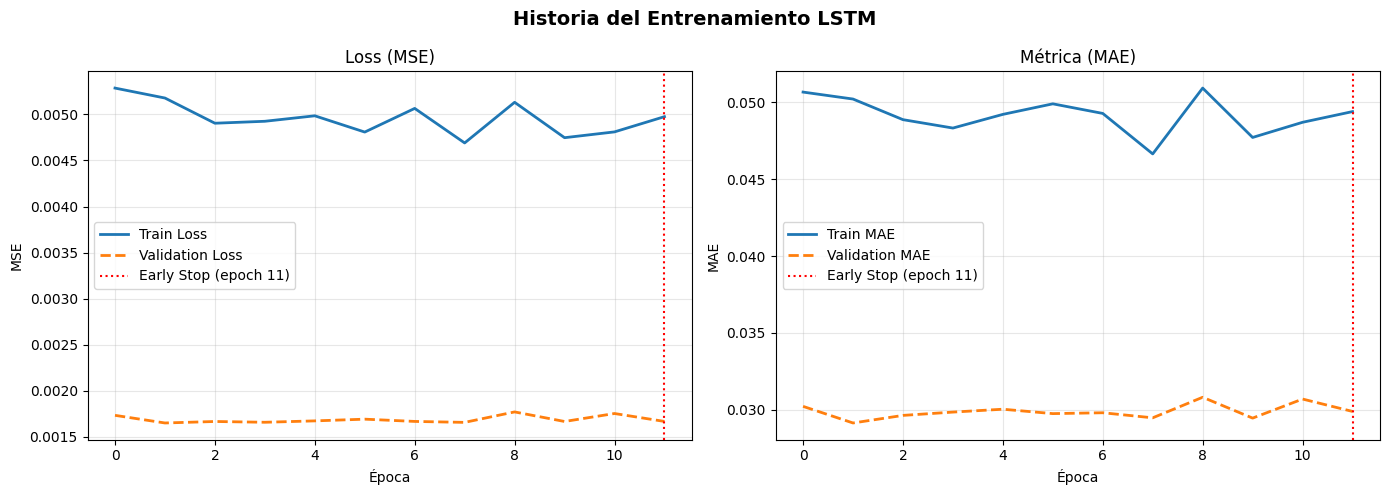

In [161]:
# Gráfico de historia del entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (MSE)
axes[0].plot(history.history["loss"],     label="Train Loss",      linewidth=2)
axes[0].plot(history.history["val_loss"], label="Validation Loss", linewidth=2, linestyle="--")
axes[0].axvline(
    x     = early_stop.stopped_epoch,
    color = "red",
    linestyle = ":",
    label = f"Early Stop (epoch {early_stop.stopped_epoch})"
)
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Métrica (MAE)
axes[1].plot(history.history["mae"],     label="Train MAE",      linewidth=2)
axes[1].plot(history.history["val_mae"], label="Validation MAE", linewidth=2, linestyle="--")
axes[1].axvline(
    x         = early_stop.stopped_epoch,
    color     = "red",
    linestyle = ":",
    label     = f"Early Stop (epoch {early_stop.stopped_epoch})"
)
axes[1].set_title("Métrica (MAE)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Historia del Entrenamiento LSTM", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Predicción en escala normalizada
y_pred_scaled = model.predict(X_test)

# Los valores escalados se convierten de nuevo a valores de temperatura reales.
pred_inv = scaler.inverse_transform(
    np.c_[pred, np.zeros((len(pred), df.shape[1] - 1))]
)[:, 0]

# Lo mismo con la serie original test
y_test_inv = scaler.inverse_transform(
    np.c_[y_test, np.zeros((len(y_test), df.shape[1] - 1))]
)[:, 0]



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


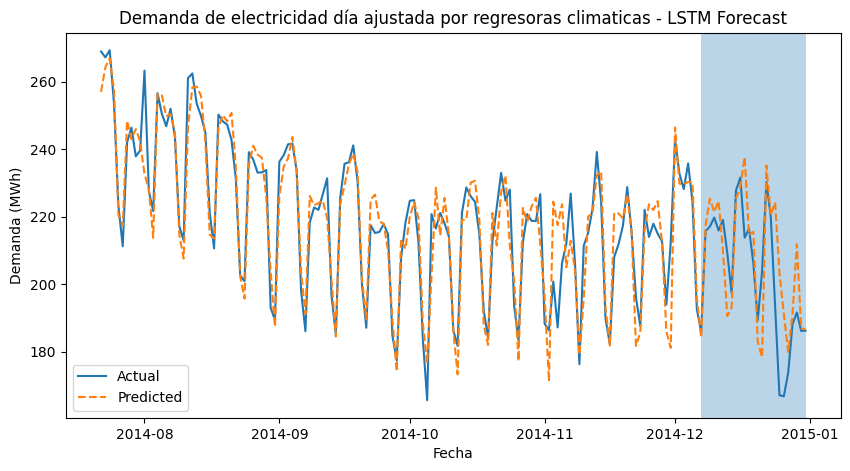

In [178]:
# Representación gráfica de los valores reales frente a los valores previstos.
time = df.index[-len(y_test):]

plt.figure(figsize=(10, 5))
plt.plot(time, y_test_inv, label="Actual")
plt.plot(time, pred_inv, linestyle="--", label="Predicted")

highlight = int(len(time) * 0.85)
plt.axvspan(time[highlight], time[-1], alpha=0.3)

plt.title("Demanda de electricidad día ajustada por regresoras climaticas - LSTM Forecast")
plt.xlabel("Fecha")
plt.ylabel("Demanda (MWh)")
plt.legend()
plt.show()

In [ ]:
# Evaluar el rendimiento del modelo
# Evaluamos el rendimiento del modelo:
# MSE: error cuadrático medio
# MAE: error promedio
# R²: precisión de las predicciones con respecto a los valores reales

mse = mean_squared_error(y_test_inv, pred_inv)
mae = mean_absolute_error(y_test_inv, pred_inv)
r2 = r2_score(y_test_inv, pred_inv)

metricas = pd.DataFrame({
    "Métrica":      ["MSE", "RMSE", "MAE", "R²"],
    "Valor":        [mse, np.sqrt(mse), mae, r2],
    "Descripción":  [
        "Error cuadrático medio",
        "Raíz del error cuadrático medio",
        "Error absoluto medio",
        "Precisión respecto a valores reales"
    ]
})

print(metricas.to_string(index=False))

Métrica     Valor                         Descripción
    MSE 92.380174              Error cuadrático medio
   RMSE  9.611461     Raíz del error cuadrático medio
    MAE  6.793307                Error absoluto medio
     R²  0.814299 Precisión respecto a valores reales


In [ ]:
# Grafico serie real vs predicha
time = df.index[-len(y_test):]

plt.figure(figsize=(10, 5))
plt.plot(time, y_test_inv, label="Actual")
plt.plot(time, pred_inv, linestyle="--", label="Predicted")

highlight = int(len(time) * 0.85)
plt.axvspan(time[highlight], time[-1], alpha=0.3)

plt.title("Delhi Climate LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

# Ejemplo 2. Empleo mensual en el sector de ocio y hostelería en EE. UU

Describiremos la modelización ARIMA estacional utilizando datos mensuales de empleo en Estados Unidos para los trabajos de ocio y hospitalidad desde enero de 2001 hasta septiembre de 2019.

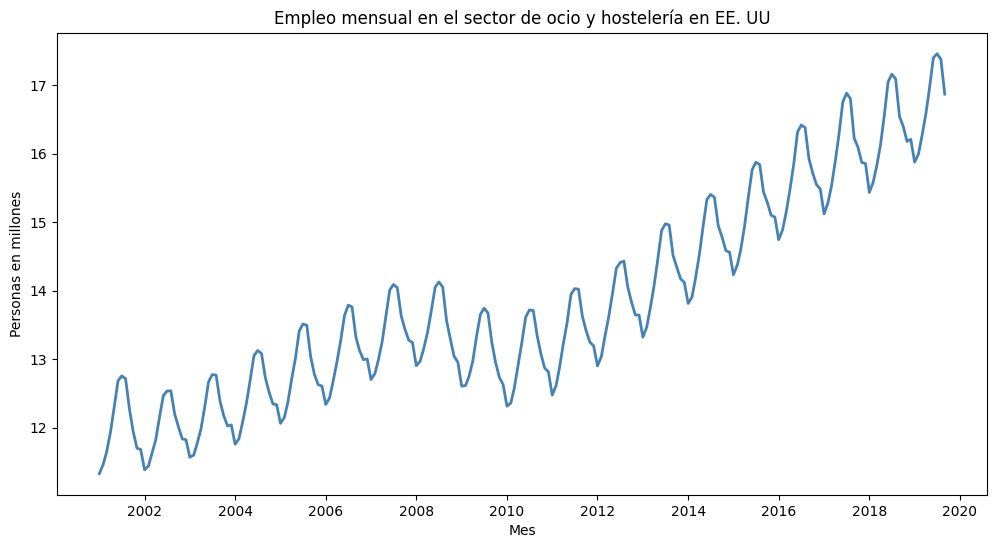

In [ ]:
# leer y ajustar datos
github_data = "https://raw.githubusercontent.com/fersalme/series-tiempo-econometria/refs/heads/main/data/us_employment.csv"
datos = pd.read_csv(github_data, parse_dates=["ds"])
datos = datos.loc[(datos["ds"] >= "2001-01-01") & (datos["unique_id"] == "Leisure and Hospitality")].reset_index(drop=True)
datos["y"] = datos["y"] / 1e3
datos = datos.set_index('ds')
datos.index = pd.DatetimeIndex(datos.index).to_period('M').to_timestamp()
serie_us_employment = datos.y

# grafico serie
plt.figure(figsize=(12, 6))
plt.plot(serie_us_employment.index, serie_us_employment, color='steelblue', linewidth=2)
plt.xlabel('Mes')
plt.ylabel('Personas en millones')
plt.title('Empleo mensual en el sector de ocio y hostelería en EE. UU')
plt.show()

In [101]:
# Paticionado de la serie
datos_modelos = datos.copy()
datos_modelos["ds"] = datos_modelos.index

fecha_corte = "2018-01-01"
datos_train = datos_modelos[datos_modelos["ds"] < pd.to_datetime(fecha_corte)]
datos_test = datos_modelos[datos_modelos["ds"] >= pd.to_datetime(fecha_corte)]

print(f"N Train : {datos_train.shape[0]}")
print(f"N Test : {datos_test.shape[0]}")

datos_train.head()

N Train : 204
N Test : 21


,unique_id,y,ds
ds,,,
2001-01-01,Leisure and Hospitality,11.328,2001-01-01
2001-02-01,Leisure and Hospitality,11.462,2001-02-01
2001-03-01,Leisure and Hospitality,11.645,2001-03-01
2001-04-01,Leisure and Hospitality,11.936,2001-04-01
2001-05-01,Leisure and Hospitality,12.297,2001-05-01


In [103]:
# SARIMA
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

m_autoarima = auto_arima(datos_train.y, seasonal=True, m=12, stepwise=False, approximation=False)
auto_sarima = ARIMA(datos_train.y, order=m_autoarima.order, seasonal_order=m_autoarima.seasonal_order).fit()

# pronostico
t_pronostico = datos_test.shape[0]
pronostico_sarima = auto_sarima.get_forecast(steps=t_pronostico)
pred_mean_sarima = pronostico_sarima.predicted_mean

C:\Users\fsalcedo\AppData\Local\miniconda3\envs\timeseries\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [125]:
# Prophet
modelo = Prophet()
modelo.fit(datos_train)

# pronostico
future = model.make_future_dataframe(periods=t_pronostico, freq="M")
pred_prophet = model.predict(future)

20:55:03 - cmdstanpy - INFO - Chain [1] start processing
20:55:03 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# Comparar el redimiento respeto al test
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

def rendimiento(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmae = root_mean_squared_error(y_true, y_pred)
    print(f"MAE:{mae} - RMAE : {rmae}")

print("Rendimiento SARIMA")
rendimiento(datos_test.y, pred_mean_sarima)
print("Rendimiento Prophet")
y_hat_prophet = pred_prophet[pred_prophet["ds"] >= pd.to_datetime(fecha_corte)]
rendimiento(datos_test.y, y_hat_prophet)
